<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 785 | Val: 192 | Test: 766


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 4.06e-04 | train loss 1.0250 acc 0.532 | val loss 0.7342 acc 0.714 *


[ResNet-50] Epoch   2/100 | LR: 4.06e-04 | train loss 0.8041 acc 0.722 | val loss 0.5701 acc 0.719 *


[ResNet-50] Epoch   3/100 | LR: 4.06e-04 | train loss 0.7132 acc 0.722 | val loss 0.7929 acc 0.693


[ResNet-50] Epoch   4/100 | LR: 4.06e-04 | train loss 0.6682 acc 0.748 | val loss 0.5760 acc 0.755


...

[ResNet-50] Epoch  18/100 | LR: 4.06e-04 | train loss 0.2748 acc 0.894 | val loss 0.9360 acc 0.708


[ResNet-50] Epoch  19/100 | LR: 4.06e-04 | train loss 0.2356 acc 0.916 | val loss 0.9143 acc 0.734


[ResNet-50] Epoch  20/100 | LR: 4.06e-04 | train loss 0.3004 acc 0.876 | val loss 0.5781 acc 0.807


[ResNet-50] Epoch  21/100 | LR: 4.06e-04 | train loss 0.2789 acc 0.911 | val loss 0.5518 acc 0.786


[ResNet-50] Epoch  22/100 | LR: 4.06e-04 | train loss 0.2552 acc 0.894 | val loss 0.5666 acc 0.828

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 22.

[ResNet-50] Restored best checkpoint (val loss = 0.4220)


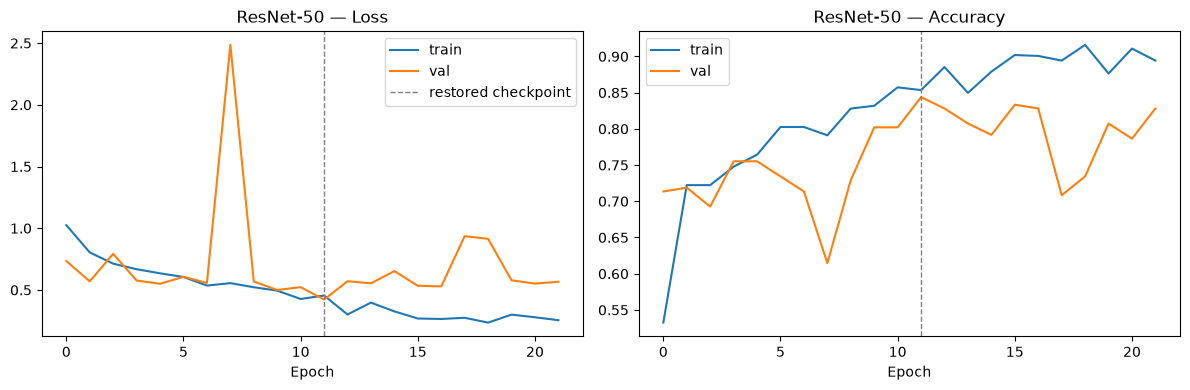

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.328


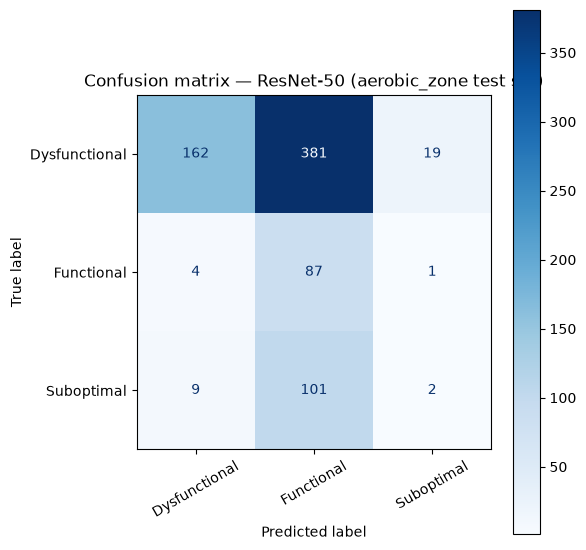

               precision    recall  f1-score   support

Dysfunctional      0.926     0.288     0.440       562
   Functional      0.153     0.946     0.263        92
   Suboptimal      0.091     0.018     0.030       112

     accuracy                          0.328       766
    macro avg      0.390     0.417     0.244       766
 weighted avg      0.711     0.328     0.359       766



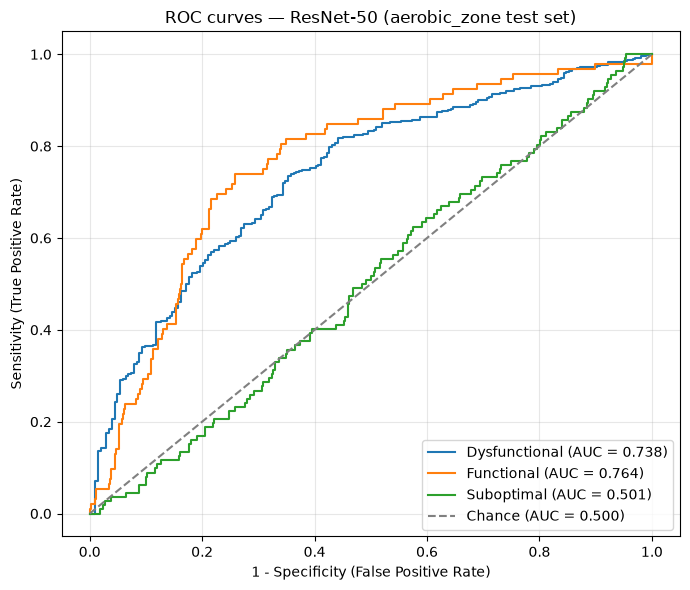

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.738
  Functional     : 0.764
  Suboptimal     : 0.501

Mean AUC (over 3/3 classes with test examples): 0.668


(np.float64(0.3276762402088773),
 {'Dysfunctional': 0.7379457120926662,
  'Functional': 0.7641110824409754,
  'Suboptimal': 0.500750873743993})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_resnet50_CapeFlats.pkl
Saved model weights to ../models/aerobic_zone_resnet50_cnn.pt
